In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("train.txt", sep=';', header=None, names=['text', 'emotion'])
print(df.head(10))

                                                text   emotion
0                            i didnt feel humiliated   sadness
1  i can go from feeling so hopeless to so damned...   sadness
2   im grabbing a minute to post i feel greedy wrong     anger
3  i am ever feeling nostalgic about the fireplac...      love
4                               i am feeling grouchy     anger
5  ive been feeling a little burdened lately wasn...   sadness
6  ive been taking or milligrams or times recomme...  surprise
7  i feel as confused about life as a teenager or...      fear
8  i have been with petronas for years i feel tha...       joy
9                                i feel romantic too      love


In [13]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [14]:
df['emotion'].unique()

<ArrowStringArray>
['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']
Length: 6, dtype: str

In [15]:
unique_emotions = df['emotion'].unique()

emotion_numbers = {}
i = 0
for emo in unique_emotions:
    emotion_numbers[emo] = i
    i += 1

df['emotion'] = df['emotion'].map(emotion_numbers)

print(df.head(10))

                                                text  emotion
0                            i didnt feel humiliated        0
1  i can go from feeling so hopeless to so damned...        0
2   im grabbing a minute to post i feel greedy wrong        1
3  i am ever feeling nostalgic about the fireplac...        2
4                               i am feeling grouchy        1
5  ive been feeling a little burdened lately wasn...        0
6  ive been taking or milligrams or times recomme...        3
7  i feel as confused about life as a teenager or...        4
8  i have been with petronas for years i feel tha...        5
9                                i feel romantic too        2


In [16]:
df['text'] = df['text'].apply(lambda x: x.lower()) # Convert all text to lowercase
# 1). lowering text 

In [17]:
import string
def remove_punc(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# this is a punctuation removal function commonly used in NLP preprocessing.

# 2). remove punctuation from text

In [18]:
df['text'] = df['text'].apply(remove_punc)
print(df.head(10))

                                                text  emotion
0                            i didnt feel humiliated        0
1  i can go from feeling so hopeless to so damned...        0
2   im grabbing a minute to post i feel greedy wrong        1
3  i am ever feeling nostalgic about the fireplac...        2
4                               i am feeling grouchy        1
5  ive been feeling a little burdened lately wasn...        0
6  ive been taking or milligrams or times recomme...        3
7  i feel as confused about life as a teenager or...        4
8  i have been with petronas for years i feel tha...        5
9                                i feel romantic too        2


In [19]:
def remove_numbers(text):
    new = ""
    for i in text:
        if not i.isdigit():
            new += i
    return new

df['text'] = df['text'].apply(remove_numbers)

# remove numbers from text

In [20]:
def remove_emojis(text):
    new = ""
    for i in text:
        if i.isascii():
            new += i
    return new

df['text'] = df['text'].apply(remove_emojis)

In [21]:
#now remove stopwords from text

# from nltk , also spacy aswell

# natural language toolkit (nltk) is a library in python that provides tools for working with human language data. 

# in nlp we split the text into tokens, and then we remove the stopwords from the tokens.
# this process is called tokenization, and it is a common preprocessing step in nlp


import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize



In [22]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Hi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
stop_words = set(stopwords.words('english'))
print(stop_words)
print(len(stop_words))

{'because', 'over', 'so', 'me', 'herself', 'only', 'himself', "i'd", 'against', 'their', 'who', "didn't", "isn't", "needn't", 'by', 'this', "hadn't", 'which', 't', 'further', 'my', "couldn't", 'these', 'weren', 'whom', 'ain', 'wouldn', 'about', 'all', 'shouldn', 'them', 'while', "i'm", 'doesn', 'is', 'be', 'own', 'at', 'being', 'each', 'there', 'those', 'not', "shan't", 'then', 'here', 'if', 'just', 'a', 'from', "they'll", "he'd", 'until', 'of', "haven't", 'does', 'on', 've', 'needn', 'why', 'nor', 'now', 'his', 'she', "we'll", 'won', 'ours', 'o', 'm', 'some', 'her', "aren't", 'your', 'same', 'theirs', 'up', "it'd", "that'll", 'hadn', 'itself', 'between', 'had', 'wasn', 'yours', 'as', 'with', "they're", 'or', 'll', "you've", 'are', 'he', "he's", "we've", 's', 'shan', "we'd", "we're", 'when', 'its', 'in', 'did', 'can', "she's", 'couldn', "doesn't", 'down', 'am', "they've", 'were', 'i', 'below', "mightn't", 'such', "wasn't", 'been', "she'd", 'ourselves', 'for', 'most', "i've", 'after', '

In [24]:
df.loc[1, 'text']

# .loc = Location → selects data by labels
# .iloc = Integer Location → selects data by integer positions/index
#df.loc[2, "Name"]     # label-based
# df.iloc[2, 0]         # position-based

'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'

In [25]:
def remove(text):
    words = word_tokenize(text)
    Cleaned = []
    for i in words:
        if i not in stop_words:
            Cleaned.append(i)
    return " ".join(Cleaned)

In [26]:
df['text'] = df['text'].apply(remove)

print(df.head(10))

                                                text  emotion
0                              didnt feel humiliated        0
1  go feeling hopeless damned hopeful around some...        0
2          im grabbing minute post feel greedy wrong        1
3  ever feeling nostalgic fireplace know still pr...        2
4                                    feeling grouchy        1
5      ive feeling little burdened lately wasnt sure        0
6  ive taking milligrams times recommended amount...        3
7     feel confused life teenager jaded year old man        4
8  petronas years feel petronas performed well ma...        5
9                                      feel romantic        2


In [27]:
df.loc[1, 'text']

'go feeling hopeless damned hopeful around someone cares awake'

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emotion'], test_size=0.2,random_state=42)



In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

bow_vect = CountVectorizer()
X_train_bow = bow_vect.fit_transform(X_train)

print(X_train_bow)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 116049 stored elements and shape (12800, 13359)>
  Coords	Values
  (0, 9568)	1
  (0, 2594)	1
  (0, 11892)	1
  (0, 1674)	1
  (0, 5453)	1
  (0, 4381)	1
  (0, 10896)	1
  (0, 6187)	1
  (0, 9835)	1
  (0, 6990)	1
  (0, 10908)	1
  (0, 6446)	1
  (0, 7268)	1
  (0, 9429)	1
  (0, 11651)	1
  (0, 10034)	1
  (0, 12830)	1
  (1, 5799)	2
  (1, 11145)	1
  (1, 4378)	1
  (1, 11427)	1
  (1, 4329)	1
  (2, 4378)	1
  (2, 6828)	1
  (2, 9101)	1
  :	:
  (12795, 6995)	1
  (12795, 10724)	1
  (12795, 6718)	1
  (12795, 2372)	1
  (12795, 9457)	1
  (12795, 2936)	1
  (12796, 4378)	1
  (12796, 3019)	1
  (12797, 11145)	1
  (12797, 4378)	1
  (12797, 6894)	1
  (12797, 11286)	1
  (12798, 4378)	1
  (12798, 11286)	1
  (12798, 11984)	1
  (12798, 10440)	1
  (12798, 7837)	1
  (12798, 13194)	1
  (12799, 4378)	1
  (12799, 10899)	1
  (12799, 10902)	1
  (12799, 3446)	1
  (12799, 6973)	1
  (12799, 10028)	1
  (12799, 13241)	1


In [30]:

X_test_bow = bow_vect.transform(X_test)


In [33]:
# The reason is that Multinomial Naive Bayes is naturally suited to word-count or word-frequency features.

# 1. What does "Multinomial" mean?

# In NLP, your document can be represented by how many times each word occurs.
# Multinomial Naive Bayes is designed to work particularly well with this kind of data.



from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score , classification_report, f1_score



In [34]:
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

pred_bow = nb_model.predict(X_test_bow)

print("accuracy_score NB_bow : ", accuracy_score(y_test, pred_bow))
print(classification_report(y_test, pred_bow))

accuracy_score NB_bow :  0.7678125
              precision    recall  f1-score   support

           0       0.75      0.95      0.84       946
           1       0.89      0.63      0.74       427
           2       0.93      0.26      0.41       296
           3       1.00      0.05      0.10       113
           4       0.85      0.57      0.68       397
           5       0.73      0.96      0.83      1021

    accuracy                           0.77      3200
   macro avg       0.86      0.57      0.60      3200
weighted avg       0.80      0.77      0.74      3200



In [35]:

tfidfVectorizer  = TfidfVectorizer()
X_train_tfidf = tfidfVectorizer.fit_transform(X_train)
X_test_tfidf = tfidfVectorizer.transform(X_test)

nb2_model = MultinomialNB()
nb2_model.fit(X_train_tfidf, y_train)

y_pred = nb2_model.predict(X_test_tfidf)

print("accuracy_score NB_tfidf: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


accuracy_score NB_tfidf:  0.6609375
              precision    recall  f1-score   support

           0       0.70      0.93      0.80       946
           1       0.93      0.29      0.44       427
           2       1.00      0.03      0.06       296
           3       1.00      0.01      0.02       113
           4       0.92      0.22      0.36       397
           5       0.60      0.99      0.74      1021

    accuracy                           0.66      3200
   macro avg       0.86      0.41      0.40      3200
weighted avg       0.76      0.66      0.58      3200



In [36]:

from sklearn.linear_model import LogisticRegression

logistic_model1 = LogisticRegression(max_iter= 1000)

logistic_model1.fit(X_train_bow,y_train)

logistic_model2 = LogisticRegression(max_iter=1000)

log_pred_bow = logistic_model1.predict(X_test_bow)

print("accuracy_score log_bow: ", accuracy_score(y_test, log_pred_bow))
print(classification_report(y_test, log_pred_bow))

accuracy_score log_bow:  0.88875
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       946
           1       0.89      0.85      0.87       427
           2       0.84      0.76      0.80       296
           3       0.86      0.72      0.78       113
           4       0.86      0.84      0.85       397
           5       0.88      0.94      0.91      1021

    accuracy                           0.89      3200
   macro avg       0.88      0.84      0.86      3200
weighted avg       0.89      0.89      0.89      3200



In [37]:

logistic_model2.fit(X_train_tfidf,y_train)

log_pred_tfidf = logistic_model2.predict(X_test_tfidf)

print("accuracy_score log_tfidf: ", accuracy_score(y_test, log_pred_tfidf))
print(classification_report(y_test, log_pred_tfidf))



from sklearn.svm import LinearSVC


svm_model1 = LinearSVC()

svm_model1.fit(X_train_bow, y_train)

y_pred_svm_bow = svm_model1.predict(X_test_bow)

print("SVM bow accuracy:", accuracy_score(y_test, y_pred_svm_bow))
print(classification_report(y_test, y_pred_svm_bow))

accuracy_score log_tfidf:  0.8615625
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       946
           1       0.90      0.81      0.86       427
           2       0.90      0.61      0.72       296
           3       0.88      0.47      0.61       113
           4       0.86      0.76      0.80       397
           5       0.81      0.96      0.88      1021

    accuracy                           0.86      3200
   macro avg       0.88      0.76      0.80      3200
weighted avg       0.87      0.86      0.86      3200

SVM bow accuracy: 0.8896875
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       946
           1       0.88      0.89      0.89       427
           2       0.82      0.79      0.80       296
           3       0.82      0.72      0.76       113
           4       0.85      0.86      0.85       397
           5       0.90      0.93      0.91      1021

    accuracy

SVM tfidf accuracy: 0.891875
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       946
           1       0.89      0.88      0.88       427
           2       0.83      0.74      0.78       296
           3       0.88      0.70      0.78       113
           4       0.87      0.85      0.86       397
           5       0.89      0.94      0.91      1021

    accuracy                           0.89      3200
   macro avg       0.88      0.84      0.86      3200
weighted avg       0.89      0.89      0.89      3200

[[883  20   6   1  13  23]
 [ 20 375   4   1  13  14]
 [  7   3 218   0   4  64]
 [  7   0   1  79  18   8]
 [ 18  18   1   8 338  14]
 [ 18   5  32   1   4 961]]


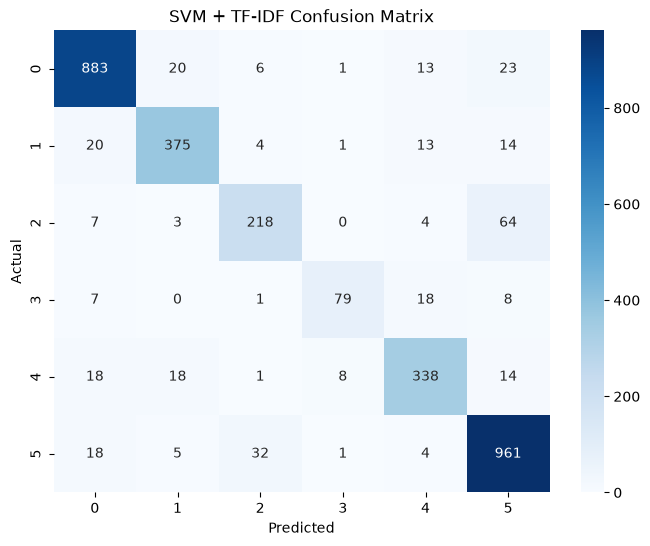

In [38]:

svm_model2 = LinearSVC()

svm_model2.fit(X_train_tfidf, y_train)

y_pred_svm_tfidf = svm_model2.predict(X_test_tfidf)

print("SVM tfidf accuracy:", accuracy_score(y_test, y_pred_svm_tfidf))
print(classification_report(y_test, y_pred_svm_tfidf))


from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm_tfidf)
print(cm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM + TF-IDF Confusion Matrix")

plt.show()

In [39]:

tfidf_bigram = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf_bigram = tfidf_bigram.fit_transform(X_train)
X_test_tfidf_bigram = tfidf_bigram.transform(X_test)

svm_bigram = LinearSVC()

svm_bigram.fit(X_train_tfidf_bigram, y_train)

pred_bigram = svm_bigram.predict(X_test_tfidf_bigram)

print("SVM TF-IDF Bigram Accuracy:",
      accuracy_score(y_test, pred_bigram))

print(classification_report(y_test, pred_bigram))

print(confusion_matrix(y_test, pred_bigram))



tfidf_trigram = TfidfVectorizer(
    ngram_range=(1, 3)
)

X_train_tfidf_trigram = tfidf_trigram.fit_transform(X_train)
X_test_tfidf_trigram = tfidf_trigram.transform(X_test)

svm_trigram = LinearSVC()

svm_trigram.fit(
    X_train_tfidf_trigram,
    y_train
)

pred_trigram = svm_trigram.predict(
    X_test_tfidf_trigram
)

print(
    "SVM TF-IDF Trigram Accuracy:",
    accuracy_score(y_test, pred_trigram)
)

print(
    classification_report(
        y_test,
        pred_trigram
    )
)

print(confusion_matrix(y_test, pred_trigram))


SVM TF-IDF Bigram Accuracy: 0.90125
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       946
           1       0.89      0.89      0.89       427
           2       0.85      0.78      0.81       296
           3       0.83      0.73      0.78       113
           4       0.87      0.84      0.86       397
           5       0.90      0.95      0.93      1021

    accuracy                           0.90      3200
   macro avg       0.88      0.86      0.87      3200
weighted avg       0.90      0.90      0.90      3200

[[887  21   7   3  13  15]
 [ 17 379   3   1  12  15]
 [  4   3 231   0   3  55]
 [  5   0   1  83  18   6]
 [ 20  17   1  12 335  12]
 [ 14   4  30   1   3 969]]
SVM TF-IDF Trigram Accuracy: 0.8990625
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       946
           1       0.90      0.88      0.89       427
           2       0.84      0.77      0.80       296
  

In [40]:

tfidf = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

C_values = [0.01, 0.1, 1, 10, 100]

results = {}

for c in C_values:

    svm_model = LinearSVC(
        C=c,
        max_iter=5000
    )

    svm_model.fit(X_train_tfidf, y_train)

    y_pred = svm_model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    results[c] = {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

    print(
        f"C = {c} | "
        f"Accuracy = {accuracy:.4f} | "
        f"Macro F1 = {macro_f1:.4f}"
    )


C = 0.01 | Accuracy = 0.5500 | Macro F1 = 0.2523
C = 0.1 | Accuracy = 0.8569 | Macro F1 = 0.7975
C = 1 | Accuracy = 0.9012 | Macro F1 = 0.8672
C = 10 | Accuracy = 0.9016 | Macro F1 = 0.8687
C = 100 | Accuracy = 0.9016 | Macro F1 = 0.8698


In [41]:

# this works brest that' why we choce this 

final_model = LinearSVC(
    C=100,
    max_iter=5000
)

final_model.fit(
    X_train_tfidf,
    y_train
)

final_pred = final_model.predict(X_test_tfidf)

print("Final Accuracy:",
      accuracy_score(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_test, final_pred)) 

cm = confusion_matrix(y_test, final_pred)

print(cm)

Final Accuracy: 0.9015625

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       946
           1       0.89      0.89      0.89       427
           2       0.83      0.79      0.81       296
           3       0.83      0.76      0.80       113
           4       0.87      0.84      0.86       397
           5       0.91      0.94      0.93      1021

    accuracy                           0.90      3200
   macro avg       0.88      0.86      0.87      3200
weighted avg       0.90      0.90      0.90      3200

[[885  22   8   3  15  13]
 [ 16 381   3   1  12  14]
 [  4   3 235   0   3  51]
 [  4   0   1  86  18   4]
 [ 19  18   1  12 335  12]
 [ 14   6  34   1   3 963]]


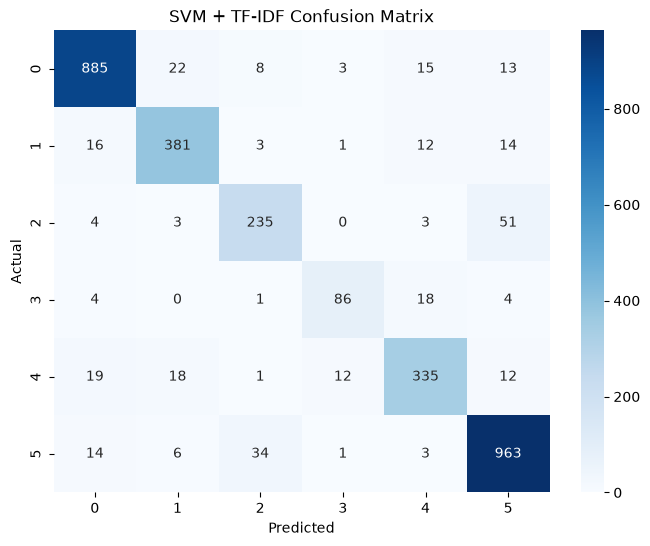

In [42]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM + TF-IDF Confusion Matrix")

plt.show()